# Chicken (Hawk-Dove) — entrega

Notebook de la entrega: corre los experimentos en Chicken con FP, RM y RandomAgent (implementaciones del equipo, en `agents/`). Persiste `history` dicts en `data/chicken/`, guarda figuras en `images/chicken/`, y registra el progreso en `logs/chicken/Chicken.log`.

Las gráficas usan los helpers de `utils.plots` (compartidos por todos los notebooks del equipo). Configuración: demos single-seed con `SEED=1` × 10000 iter para las pairings (FP×FP, RM×RM, FP×RM, RandomAgent×{Random, FP, RM}), y régimen multi-seed corto con `SEEDS=range(100)` × 200 iter para el scatter en el espacio de utilidades.

**Métrica específica de Chicken**: frecuencia del outcome catastrófico $(S, S) = (0, 0)$.

## Setup

In [1]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Agentes del equipo
from games.chicken import Chicken
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching
from agents.random_agent import RandomAgent

# Infraestructura compartida (utils/)
from utils.logger import get_logger
from utils.storage import cached, savefig
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_instantaneous_vs_average_policy,
    plot_joint_action_heatmap,
    plot_utility_space,
)

# Helper para ejecutar y cachear corridas, y para distribuciones de joint actions
from utils import experiments as exp

log = get_logger(notebook_name='Chicken')

# Constantes del experimento
ITERATIONS = 10000
SEED = 1
SEEDS = [1, 7, 42]           # multi-seed para el heatmap promediado
SEEDS_MANY = list(range(100))
ITER_FEW = 200               # régimen pre-colapso
LABELS = ['S', 'L']          # acción 0 = S (Hawk/Seguir), 1 = L (Dove/Esquivar)

# Equilibrio mixto simetrico de Chicken (cada agente juega S con prob 1/3, L con 2/3)
NASH_MIXED = {
    'agent_0': np.array([1/3, 2/3]),
    'agent_1': np.array([1/3, 2/3]),
}

log.info('Setup Chicken listo')

# Pairings y constantes multi-seed (usados por el scatter en espacio de utilidades)
chicken_pairs = {
    'FP vs FP':  [(FictitiousPlay, {}), (FictitiousPlay, {})],
    'RM vs RM':  [(RegretMatching, {}), (RegretMatching, {})],
    'FP vs RM':  [(FictitiousPlay, {}), (RegretMatching, {})],
}



2026-05-27 21:57:18 | INFO    | Setup Chicken listo


In [2]:
# Payoffs de Chicken indexados por (acción_agent_0, acción_agent_1) → (r0, r1)
# 0 = S (Hawk/Seguir), 1 = L (Dove/Esquivar)
CHICKEN_PAYOFFS = np.array([
    [[0, 0], [7, 2]],   # (S, S)=(0,0); (S, L)=(7,2)
    [[2, 7], [6, 6]],   # (L, S)=(2,7); (L, L)=(6,6)
])


def reward_history_from_actions(action_history):
    """Reconstruye reward por iter de cada agente a partir de las acciones jugadas."""
    a0 = action_history['agent_0'].astype(int)
    a1 = action_history['agent_1'].astype(int)
    rewards = CHICKEN_PAYOFFS[a0, a1]
    return rewards[:, 0], rewards[:, 1]

## FictitiousPlay vs FictitiousPlay

FP modela al oponente como una distribución empírica sobre acciones pasadas y juega greedy (mejor respuesta). En Chicken la mejor respuesta cambia de signo según la creencia: si el rival es percibido como Hawk-pesado, conviene jugar Dove (L: 2 > 0); si es Dove-pesado, conviene jugar Hawk (S: 7 > 6). Esto puede llevar a oscilaciones o a un colapso asimétrico.

In [3]:
log.info('FP vs FP en Chicken — iniciando experimento')

agent_pair_fp = [(FictitiousPlay, {}), (FictitiousPlay, {})]
history_fp = exp.cached_run('chicken_history_fp_vs_fp', Chicken(), agent_pair_fp,
                              iterations=ITERATIONS, seed=SEED)

log.info(f'FP vs FP: política final agent_0={history_fp["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:18 | INFO    | FP vs FP en Chicken — iniciando experimento


2026-05-27 21:57:18 | INFO    | FP vs FP: política final agent_0=[0.999 0.001], agent_1=[0. 1.]


### Evolución de la política

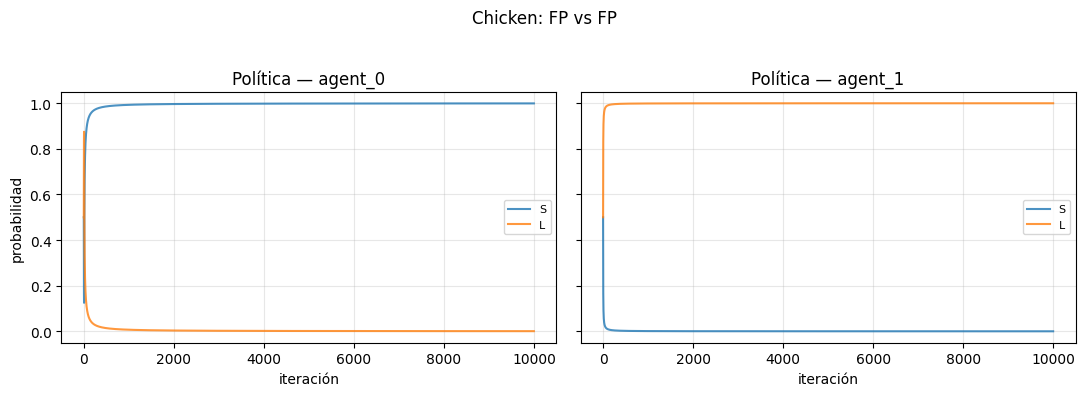

In [4]:
plot_policy_evolution(history_fp, action_labels=LABELS,
                       title='Chicken: FP vs FP', save='chicken/policy_evolution_fp_vs_fp')
plt.show()

### Distancia al Nash mixto

En Chicken el equilibrio mixto simétrico es $(1/3, 2/3)$ (cada agente juega S con prob 1/3). La dinámica de FP×FP converge a UN equilibrio puro asimétrico, por lo que la distancia al mixto **no tiende a 0**: a medida que cada agente fija un rol (Hawk o Dove), la distancia crece y se estabiliza.

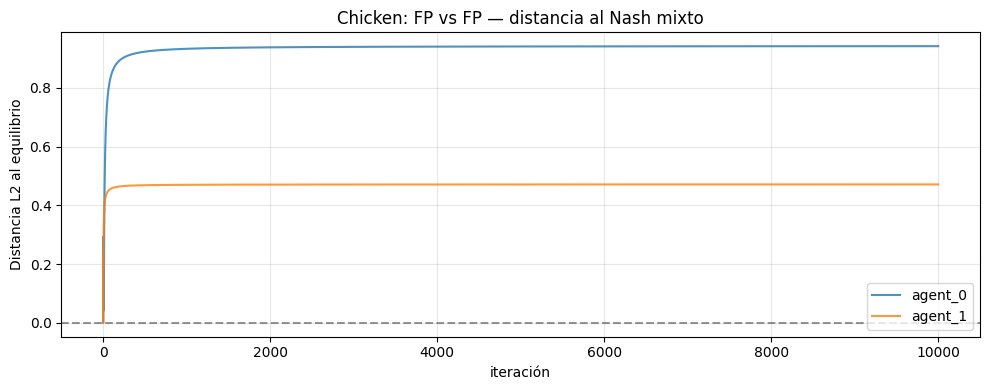

In [5]:
plot_distance_to_nash(history_fp, nash=NASH_MIXED,
                       title='Chicken: FP vs FP — distancia al Nash mixto',
                       save='chicken/distance_to_nash_fp_vs_fp')
plt.show()


### Reward promedio acumulado

Al converger los agentes a roles asimétricos (uno juega S, el otro L), el reward promedio acumulado tiende a $(7, 2)$ o $(2, 7)$ según qué agente terminó como Hawk.

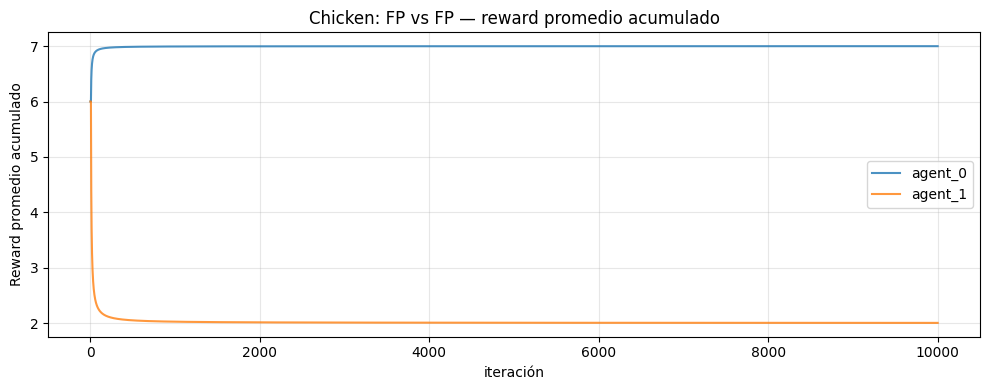

In [6]:
plot_cumulative_average_reward(history_fp, max_iter=ITERATIONS,
                                title='Chicken: FP vs FP — reward promedio acumulado',
                                save='chicken/reward_cum_avg_fp_vs_fp')
plt.show()


## RegretMatching vs RegretMatching

RM ajusta su política proporcionalmente a los regrets positivos acumulados. En Chicken la dinámica anti-coordinativa es interesante: cuando ambos juegan Hawk obtienen 0 y el regret de Dove crece (habrían tenido 2 contra Hawk); cuando ambos juegan Dove obtienen 6 pero el regret de Hawk también crece (habrían tenido 7 contra Dove). Estos regrets opuestos pueden producir oscilación más rica que en BoS.

In [7]:
log.info('RM vs RM en Chicken — iniciando experimento')

agent_pair_rm = [(RegretMatching, {}), (RegretMatching, {})]
history_rm = exp.cached_run('chicken_history_rm_vs_rm', Chicken(), agent_pair_rm,
                              iterations=ITERATIONS, seed=SEED)

log.info(f'RM vs RM: política promedio final agent_0={history_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:18 | INFO    | RM vs RM en Chicken — iniciando experimento


2026-05-27 21:57:19 | INFO    | RM vs RM: política promedio final agent_0=[0.001 0.999], agent_1=[0.999 0.001]


### Política promedio aprendida

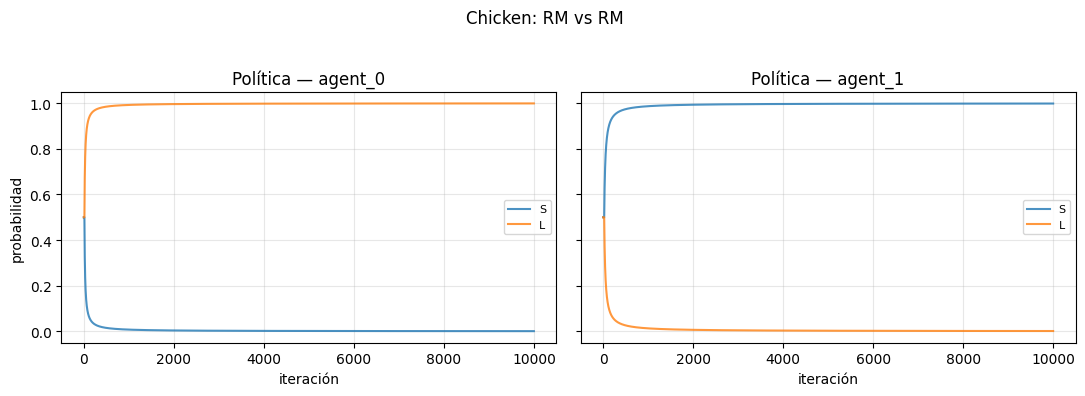

In [8]:
plot_policy_evolution(history_rm, action_labels=LABELS,
                       title='Chicken: RM vs RM', save='chicken/policy_evolution_rm_vs_rm')
plt.show()

### Distancia al Nash mixto

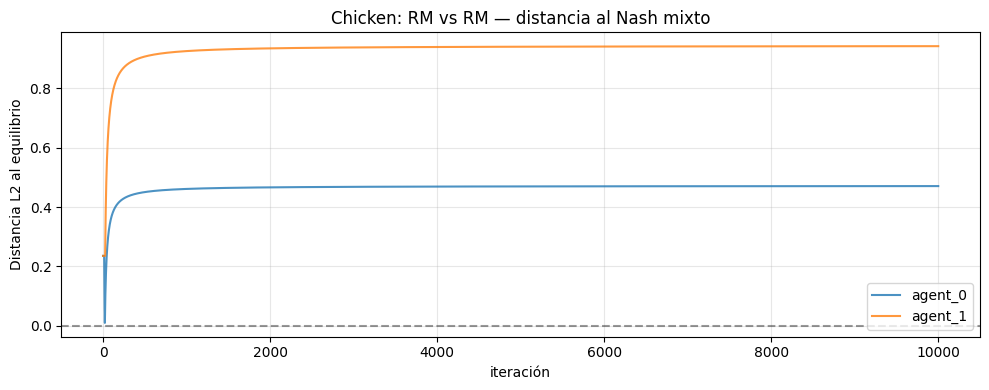

In [9]:
plot_distance_to_nash(history_rm, nash=NASH_MIXED,
                       title='Chicken: RM vs RM — distancia al Nash mixto',
                       save='chicken/distance_to_nash_rm_vs_rm')
plt.show()


### Reward promedio acumulado

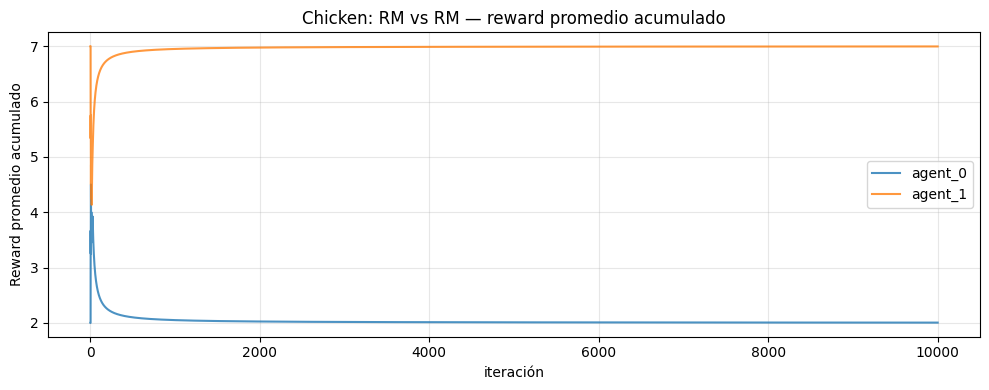

In [10]:
plot_cumulative_average_reward(history_rm, max_iter=ITERATIONS,
                                title='Chicken: RM vs RM — reward promedio acumulado',
                                save='chicken/reward_cum_avg_rm_vs_rm')
plt.show()


### Regrets acumulados

En Chicken los regrets pueden crecer en ambas direcciones según las jugadas del oponente — esperamos curvas menos monotónicas que en BoS.

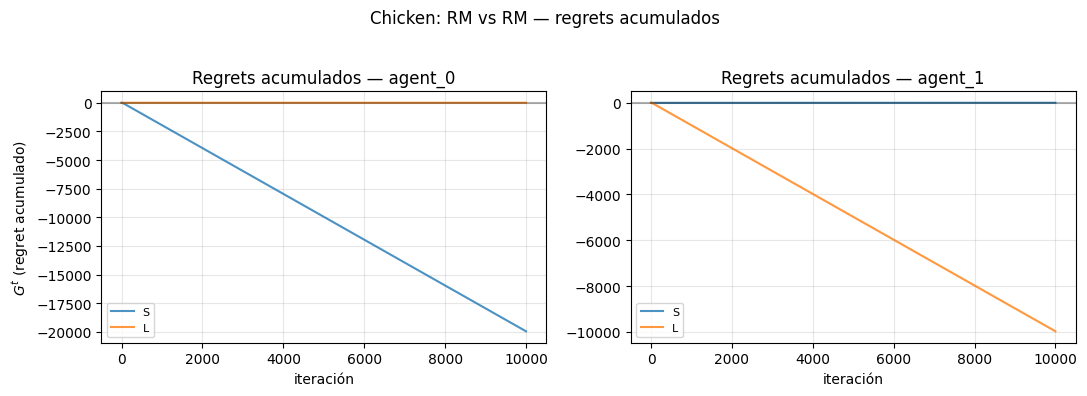

In [11]:
plot_cumulative_regret(history_rm, action_labels=LABELS,
                        title='Chicken: RM vs RM — regrets acumulados',
                        save='chicken/cum_regrets_rm_vs_rm')
plt.show()

### Regret promedio positivo / t

Validación de la garantía no-regret. Aunque en Chicken la dinámica converge a un puro y los regrets crecen, el regret positivo promedio normalizado por $t$ debe tender a 0.

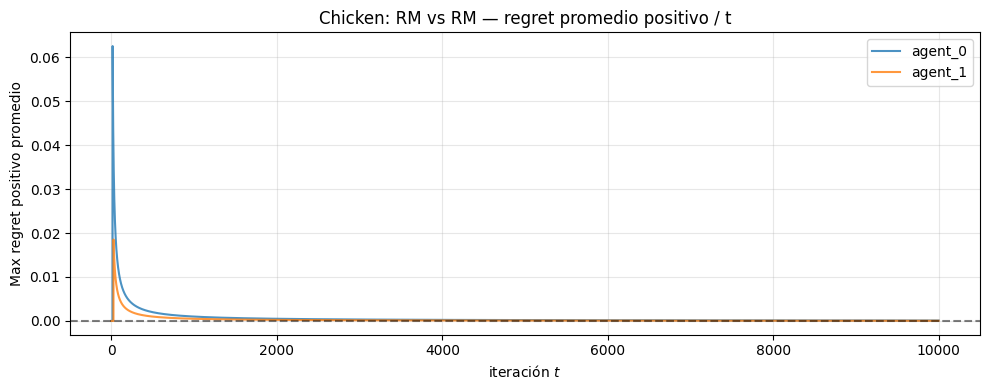

In [12]:
plot_average_positive_regret(history_rm,
                              title='Chicken: RM vs RM — regret promedio positivo / t',
                              save='chicken/avg_positive_regret_rm_vs_rm')
plt.show()


### Política instantánea vs promedio temporal

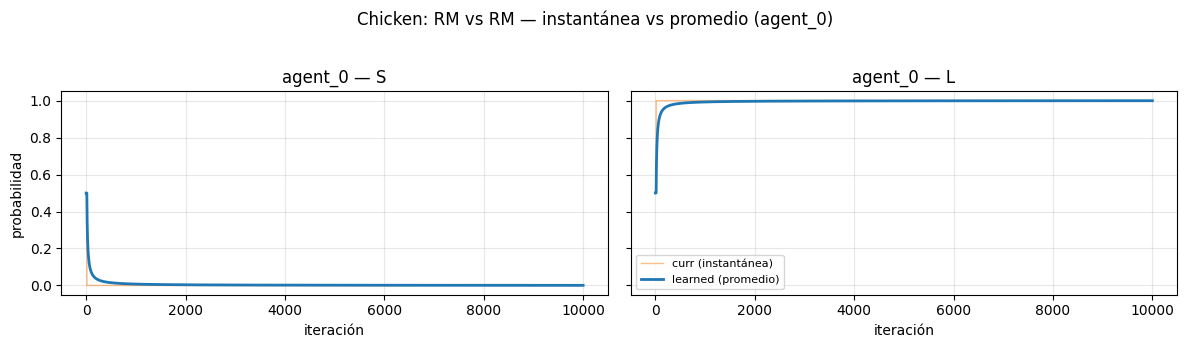

In [13]:
plot_instantaneous_vs_average_policy(history_rm, action_labels=LABELS,
                                      title='Chicken: RM vs RM — instantánea vs promedio (agent_0)',
                                      save='chicken/curr_vs_avg_policy_rm_vs_rm')
plt.show()

## FictitiousPlay vs RegretMatching

Pairing heterogénea: esperamos que FP imponga un patrón y RM se acomode. Como Chicken es anti-coordinativo, "acomodarse" significa que RM termina jugando la acción opuesta a la que FP está dominando.

In [14]:
log.info('FP vs RM en Chicken — iniciando experimento')

agent_pair_fp_rm = [(FictitiousPlay, {}), (RegretMatching, {})]
history_fp_rm = exp.cached_run('chicken_history_fp_vs_rm', Chicken(), agent_pair_fp_rm,
                                 iterations=ITERATIONS, seed=SEED)

log.info(f'FP vs RM: política final FP={history_fp_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'RM promedio={history_fp_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:20 | INFO    | FP vs RM en Chicken — iniciando experimento


2026-05-27 21:57:20 | INFO    | FP vs RM: política final FP=[0. 1.], RM promedio=[1. 0.]


### Políticas aprendidas

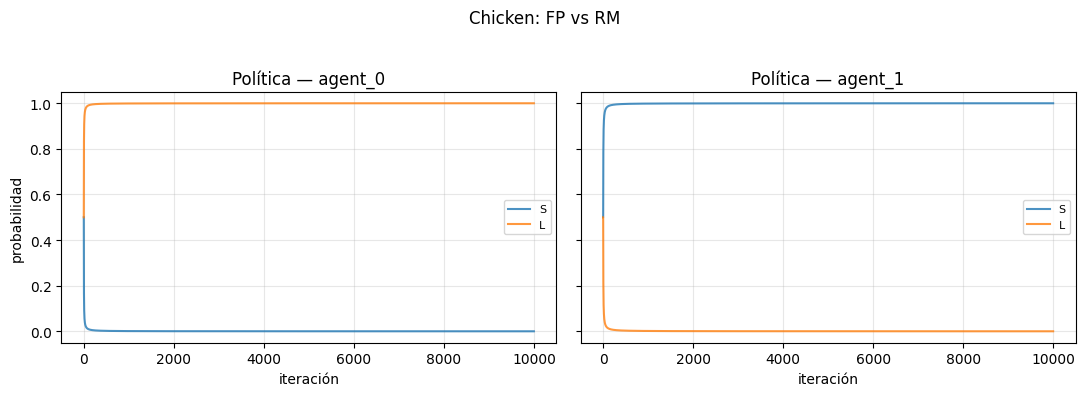

In [15]:
plot_policy_evolution(history_fp_rm, action_labels=LABELS,
                       title='Chicken: FP vs RM', save='chicken/policy_evolution_fp_vs_rm')
plt.show()

### Distancia al equilibrio + reward acumulado

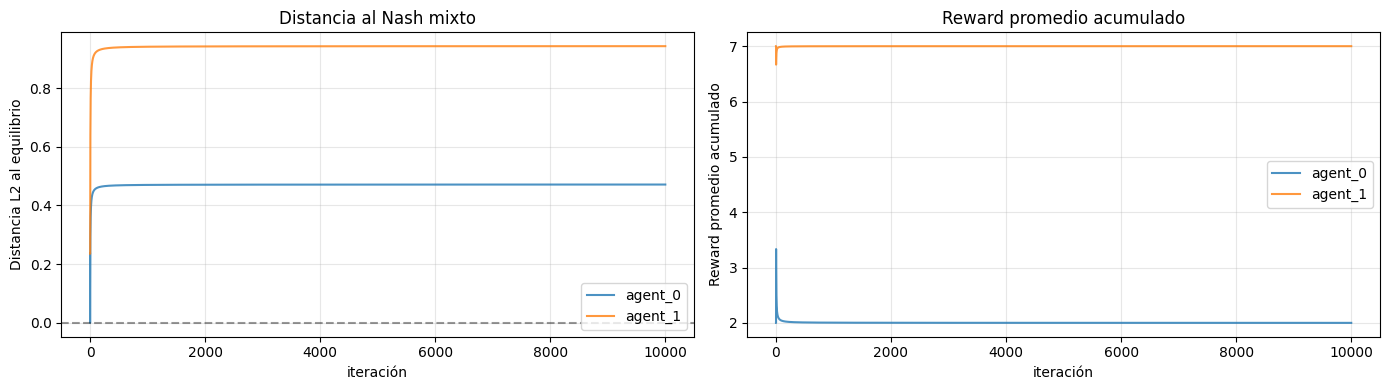

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rm, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rm,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('chicken/distance_and_reward_fp_vs_rm')
plt.show()


### RM: política instantánea vs promedio temporal

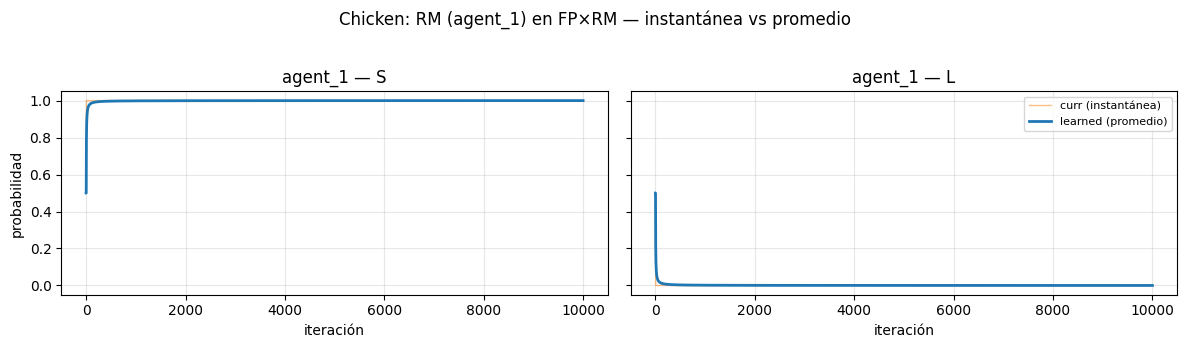

In [17]:
plot_instantaneous_vs_average_policy(history_fp_rm, action_labels=LABELS,
                                       agent='agent_1',
                                       title='Chicken: RM (agent_1) en FP×RM — instantánea vs promedio',
                                       save='chicken/curr_vs_avg_policy_rm_in_fp_vs_rm')
plt.show()


## RandomAgent vs RandomAgent

*Baseline puro: políticas planas en 0.5/0.5. Esperamos reward acumulado promedio cercano al promedio de las 4 celdas: $(0+7+2+6)/4 = 3.75$ para agent_0 y $(0+2+7+6)/4 = 3.75$ para agent_1. La frecuencia del outcome catastrófico (S, S) debería ser ~25%.*

2026-05-27 21:57:21 | INFO    | Random vs Random en Chicken — iniciando experimento


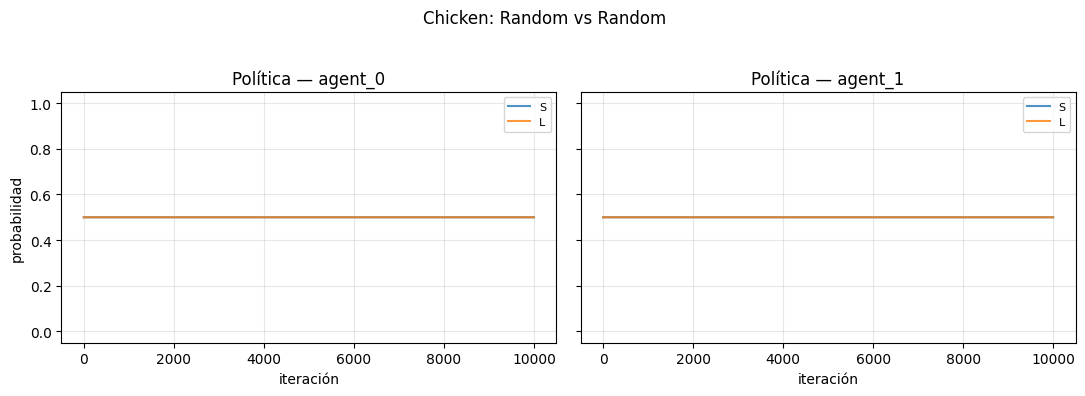

Reward acumulado promedio: agent_0=3.738, agent_1=3.737  (esperado ~3.75)
Frecuencia (S, S) catastrófico: 0.253  (esperado ~0.25)


In [18]:
log.info('Random vs Random en Chicken — iniciando experimento')

agent_pair_rnd = [(RandomAgent, {}), (RandomAgent, {})]
history_rnd = exp.cached_run('chicken_history_rnd_vs_rnd', Chicken(), agent_pair_rnd,
                              iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_rnd, action_labels=LABELS,
                       title='Chicken: Random vs Random',
                       save='chicken/policy_evolution_rnd_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_rnd['action_history'])
freq_ss = ((history_rnd['action_history']['agent_0'] == 0) & (history_rnd['action_history']['agent_1'] == 0)).mean()
print(f'Reward acumulado promedio: agent_0={r0.mean():.3f}, agent_1={r1.mean():.3f}  (esperado ~3.75)')
print(f'Frecuencia (S, S) catastrófico: {freq_ss:.3f}  (esperado ~0.25)')

## FictitiousPlay vs RandomAgent

*Contra un oponente uniforme, FP calcula: $E[u_0|S] = 0.5 \cdot 0 + 0.5 \cdot 7 = 3.5$, $E[u_0|L] = 0.5 \cdot 2 + 0.5 \cdot 6 = 4$. Dove domina, así que FP debería converger a L puro. Random sigue 50/50. Esperamos reward agent_0 $\approx 4$, agent_1 $\approx (0.5 \cdot 2 + 0.5 \cdot 6) = 4$ (ambos juegan en parte L → ganancias razonables).*

2026-05-27 21:57:21 | INFO    | FP vs Random en Chicken — iniciando experimento


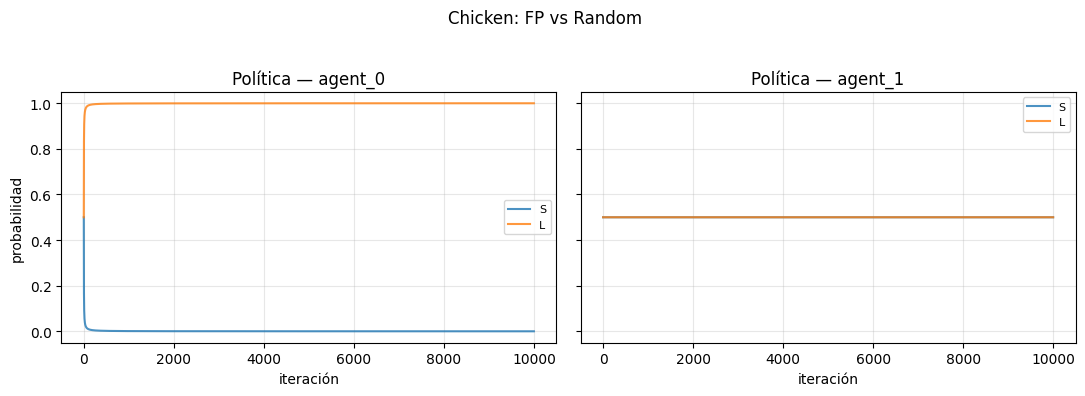

Reward acumulado promedio: FP=3.947, Random=6.513  (esperado ~4.0 / ~4.0)
Frecuencia (S, S) catastrófico: 0.000  (esperado ~0 si FP va a L)


In [19]:
log.info('FP vs Random en Chicken — iniciando experimento')

agent_pair_fp_rnd = [(FictitiousPlay, {}), (RandomAgent, {})]
history_fp_rnd = exp.cached_run('chicken_history_fp_vs_rnd', Chicken(), agent_pair_fp_rnd,
                                  iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_fp_rnd, action_labels=LABELS,
                       title='Chicken: FP vs Random',
                       save='chicken/policy_evolution_fp_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_fp_rnd['action_history'])
freq_ss = ((history_fp_rnd['action_history']['agent_0'] == 0) & (history_fp_rnd['action_history']['agent_1'] == 0)).mean()
print(f'Reward acumulado promedio: FP={r0.mean():.3f}, Random={r1.mean():.3f}  (esperado ~4.0 / ~4.0)')
print(f'Frecuencia (S, S) catastrófico: {freq_ss:.3f}  (esperado ~0 si FP va a L)')

### Distancia al equilibrio + reward acumulado

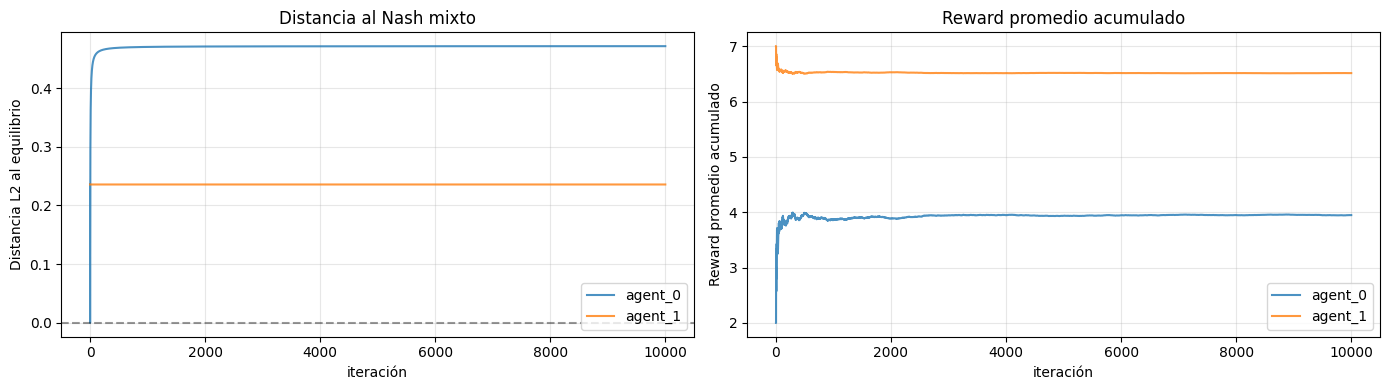

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rnd, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rnd,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('chicken/distance_and_reward_fp_vs_rnd')
plt.show()


## RegretMatching vs RandomAgent

*Mismo razonamiento: contra Random uniforme, Dove acumula más regret esperado que Hawk para RM. La política promedio de RM debería converger a L puro. Reward esperado idéntico a FP vs Random.*

2026-05-27 21:57:21 | INFO    | RM vs Random en Chicken — iniciando experimento


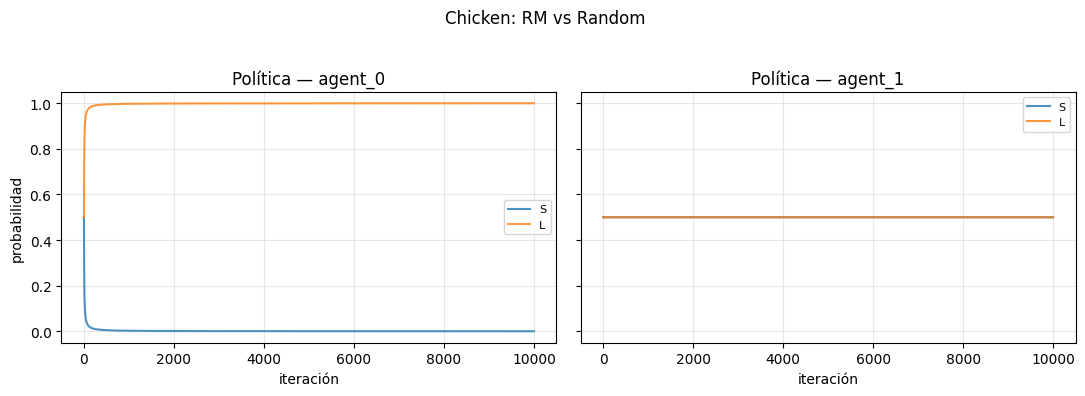

Reward acumulado promedio: RM=3.947, Random=6.512  (esperado ~4.0 / ~4.0)
Frecuencia (S, S) catastrófico: 0.000  (esperado ~0 si RM va a L)


In [21]:
log.info('RM vs Random en Chicken — iniciando experimento')

agent_pair_rm_rnd = [(RegretMatching, {}), (RandomAgent, {})]
history_rm_rnd = exp.cached_run('chicken_history_rm_vs_rnd', Chicken(), agent_pair_rm_rnd,
                                  iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_rm_rnd, action_labels=LABELS,
                       title='Chicken: RM vs Random',
                       save='chicken/policy_evolution_rm_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_rm_rnd['action_history'])
freq_ss = ((history_rm_rnd['action_history']['agent_0'] == 0) & (history_rm_rnd['action_history']['agent_1'] == 0)).mean()
print(f'Reward acumulado promedio: RM={r0.mean():.3f}, Random={r1.mean():.3f}  (esperado ~4.0 / ~4.0)')
print(f'Frecuencia (S, S) catastrófico: {freq_ss:.3f}  (esperado ~0 si RM va a L)')

### Distancia al equilibrio + reward acumulado

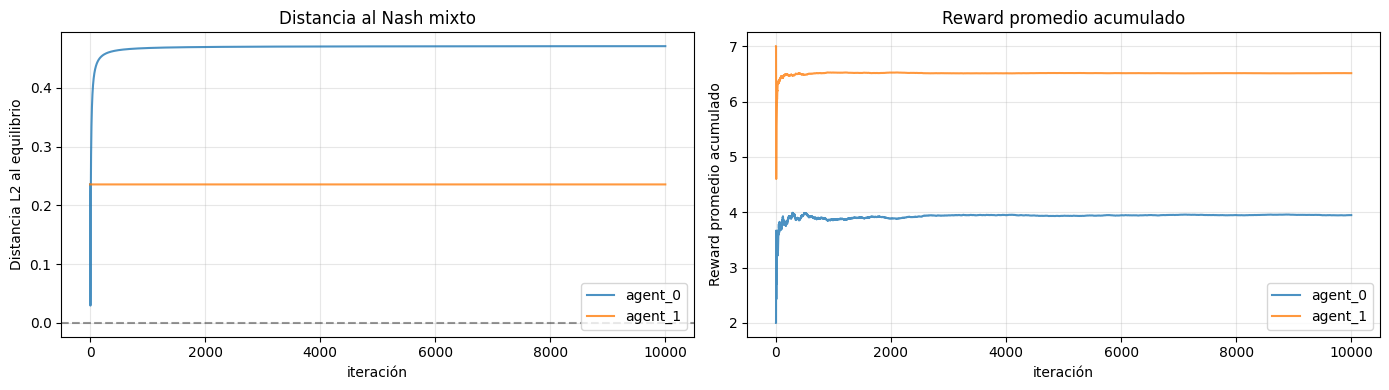

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_rm_rnd, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_rm_rnd,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('chicken/distance_and_reward_rm_vs_rnd')
plt.show()


### Regrets acumulados

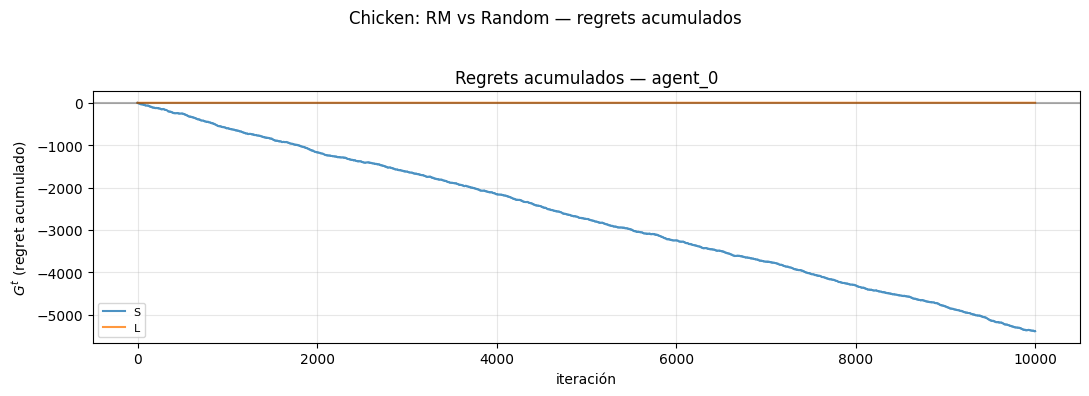

In [23]:
plot_cumulative_regret(history_rm_rnd, action_labels=LABELS,
                        title='Chicken: RM vs Random — regrets acumulados',
                        save='chicken/cum_regrets_rm_vs_rnd')
plt.show()


### Regret promedio positivo / t

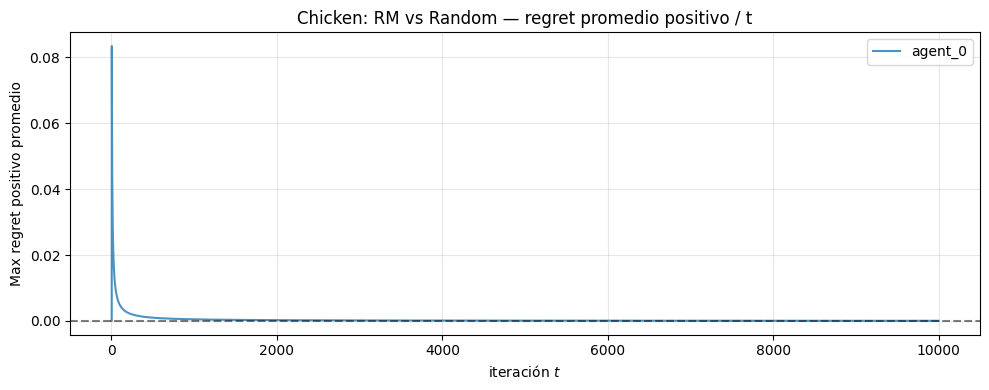

In [24]:
plot_average_positive_regret(history_rm_rnd,
                              title='Chicken: RM vs Random — regret promedio positivo / t',
                              save='chicken/avg_positive_regret_rm_vs_rnd')
plt.show()


### RM: política instantánea vs promedio temporal

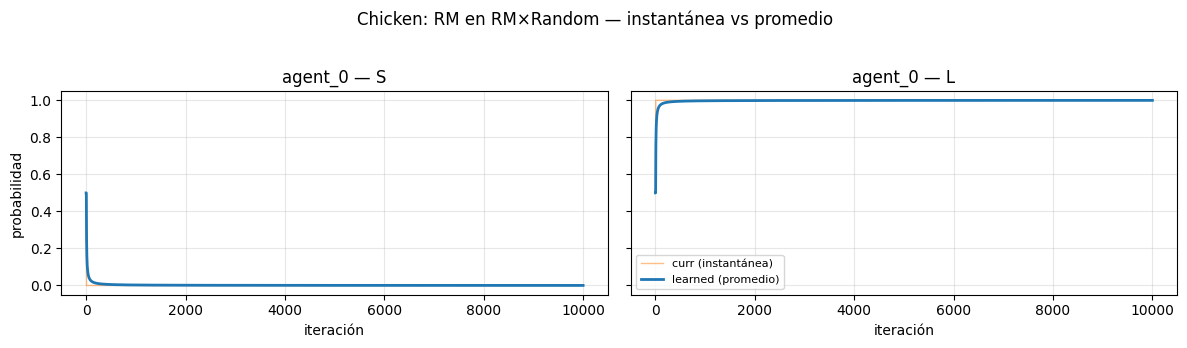

In [25]:
plot_instantaneous_vs_average_policy(history_rm_rnd, action_labels=LABELS,
                                       agent='agent_0',
                                       title='Chicken: RM en RM×Random — instantánea vs promedio',
                                       save='chicken/curr_vs_avg_policy_rm_in_rm_vs_rnd')
plt.show()


## Distribución empírica de acciones jugadas

Como en BoS, la `learned_policy` es un promedio acumulado que oculta el transient. Graficamos la frecuencia empírica de **S (Hawk)** en una ventana móvil de 50 iteraciones para los primeros 500 pasos. Si los algoritmos oscilan entre Hawk y Dove (anti-coordinación), debería verse acá.

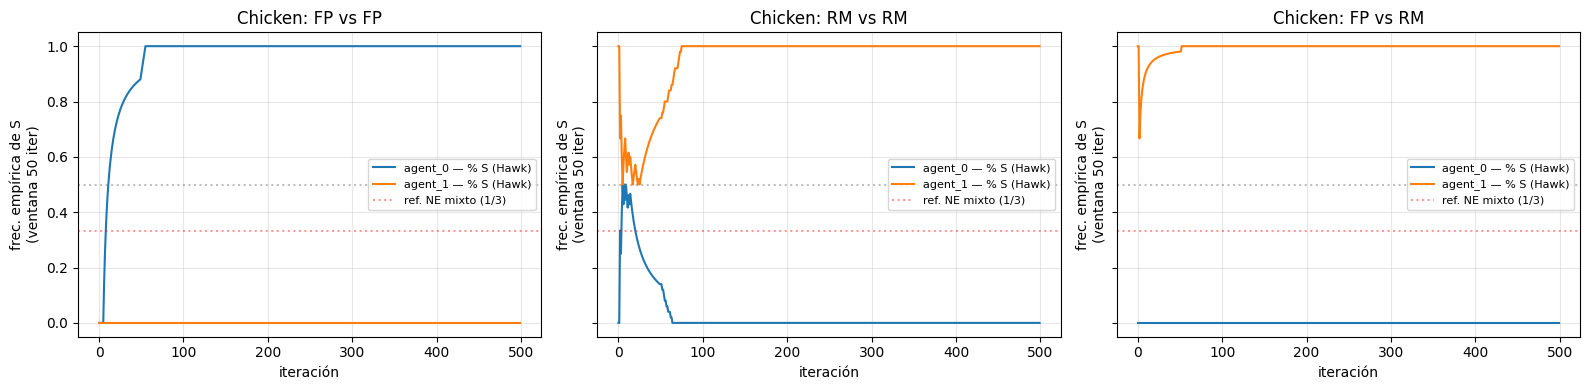

In [26]:
WINDOW = 50
HORIZON = 500


def rolling_action_freq(actions, n_actions, window):
    T = len(actions)
    cum = np.zeros((T + 1, n_actions))
    for a in range(n_actions):
        cum[1:, a] = np.cumsum(actions == a)
    freq = np.zeros((T, n_actions))
    for t in range(T):
        start = max(0, t - window + 1)
        freq[t] = (cum[t + 1] - cum[start]) / (t - start + 1)
    return freq


pairings_single = {
    'FP vs FP':  history_fp,
    'RM vs RM':  history_rm,
    'FP vs RM':  history_fp_rm,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, hist) in zip(axes, pairings_single.items()):
    for agent_id, color in zip(['agent_0', 'agent_1'], ['tab:blue', 'tab:orange']):
        actions = hist['action_history'][agent_id][:HORIZON]
        freq = rolling_action_freq(actions, n_actions=2, window=WINDOW)
        ax.plot(freq[:, 0], label=f'{agent_id} — % S (Hawk)', color=color, linewidth=1.5)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(1/3, color='red', linestyle=':', alpha=0.4, label='ref. NE mixto (1/3)')
    ax.set_title(f'Chicken: {name}')
    ax.set_xlabel('iteración')
    ax.set_ylabel(f'frec. empírica de S\n(ventana {WINDOW} iter)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc='center right', fontsize=8)
plt.tight_layout()
savefig('chicken/empirical_action_freq_single_seed')
plt.show()

## Visualización en el espacio de utilidades

Reproducimos el diagrama clásico de Chicken en el espacio de utilidades. Los puntos relevantes:

- **NE puros** $(7, 2)$ y $(2, 7)$ — asimétricos.
- **NE mixto** $(14/3, 14/3) \approx (4.67, 4.67)$ — simétrico, Pareto-domina al CE fair.
- **CE fair** $(4.5, 4.5)$ — midpoint del segmento entre los puros.
- **(L, L) Pareto-óptimo** $(6, 6)$ — NO es NE pero domina a todos los otros.
- **(S, S) catastrófico** $(0, 0)$ — el outcome que queremos evitar.

In [27]:
# Equilibrios y segmento de CEs para Chicken
CHICKEN_EQUILIBRIA = [
    {'pos': (7, 2),       'label': 'Eq-Nash puros',          'coord_text': '(7, 2)',       'color': 'black',  's': 120, 'text_offset': (8, 6)},
    {'pos': (2, 7),                                      'coord_text': '(2, 7)',       'color': 'black',  's': 120, 'text_offset': (8, 6)},
    {'pos': (14/3, 14/3), 'label': 'Eq-Nash mixto',           'coord_text': '(14/3, 14/3)', 'color': 'red',    'marker': 's', 's': 100, 'text_offset': (8, 6)},
    {'pos': (4.5, 4.5),   'label': 'Eq-Correlacionado igualitario',            'coord_text': '(4.5, 4.5)',   'color': 'green',  'marker': 'D', 's': 100, 'text_offset': (-65, -15)},
    {'pos': (6, 6),       'label': '(L,L) Pareto-óptimo', 'coord_text': '(6, 6)',       'color': 'orange', 'marker': '*', 's': 200, 'text_offset': (8, 6)},
    {'pos': (0, 0),       'label': '(S,S) catastrófico',  'coord_text': '(0, 0)',       'color': 'darkred','marker': 'X', 's': 120, 'text_offset': (8, 6)},
]
CHICKEN_SEGMENTS = [
    {'start': (7, 2), 'end': (2, 7), 'label': 'segmento Eq-Correlacionado'},
]

### A — Trayectoria de utilidad acumulada (single-seed)

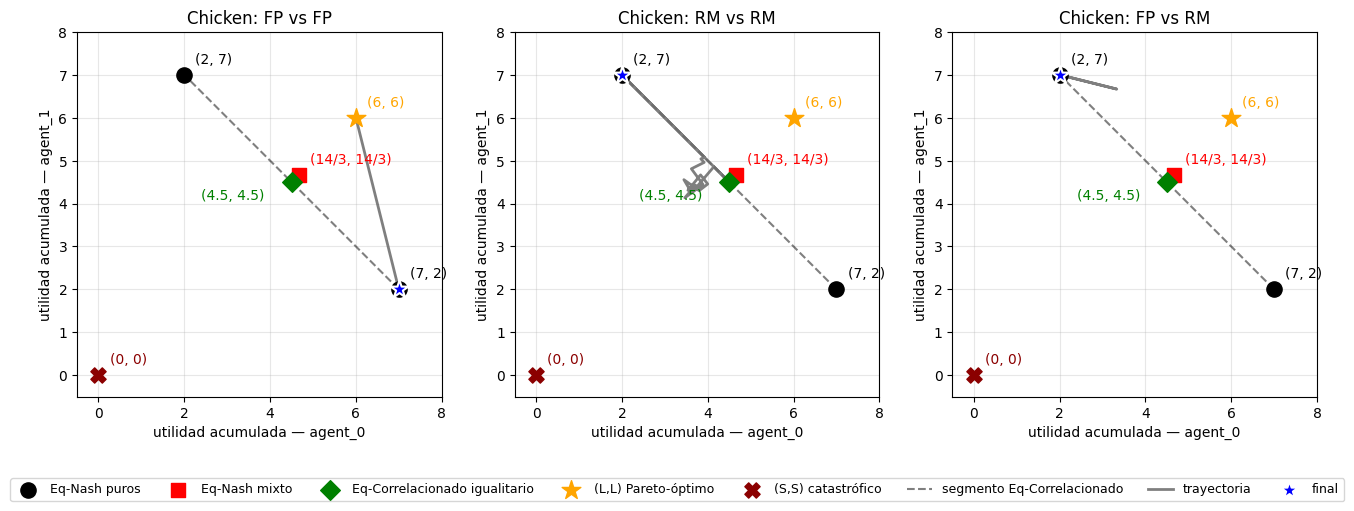

In [28]:
pairings_single = {
    'FP vs FP':  history_fp,
    'RM vs RM':  history_rm,
    'FP vs RM':  history_fp_rm,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, hist) in zip(axes, pairings_single.items()):
    r0, r1 = reward_history_from_actions(hist['action_history'])
    r0_cum = np.cumsum(r0) / np.arange(1, len(r0) + 1)
    r1_cum = np.cumsum(r1) / np.arange(1, len(r1) + 1)
    plot_utility_space(
        equilibria=CHICKEN_EQUILIBRIA,
        segments=CHICKEN_SEGMENTS,
        annotate_equilibria=True,
        ax=ax,
        title=f'Chicken: {name}',
        xlim=(-0.5, 8),
        ylim=(-0.5, 8),
        xlabel='utilidad acumulada — agent_0',
        ylabel='utilidad acumulada — agent_1',
        show_legend=False,
    )
    ax.plot(r0_cum, r1_cum, color='dimgray', alpha=0.85, linewidth=2,
            label='trayectoria', zorder=3)
    ax.scatter(r0_cum[-1], r1_cum[-1], marker='*', s=180, color='blue',
               edgecolor='white', linewidth=1.5, zorder=6, label='final')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=len(labels), fontsize=9, frameon=True)

savefig('chicken/utility_space_trajectory')
plt.show()


### B — Scatter multi-seed en el espacio de utilidades (100 seeds × 200 iter)

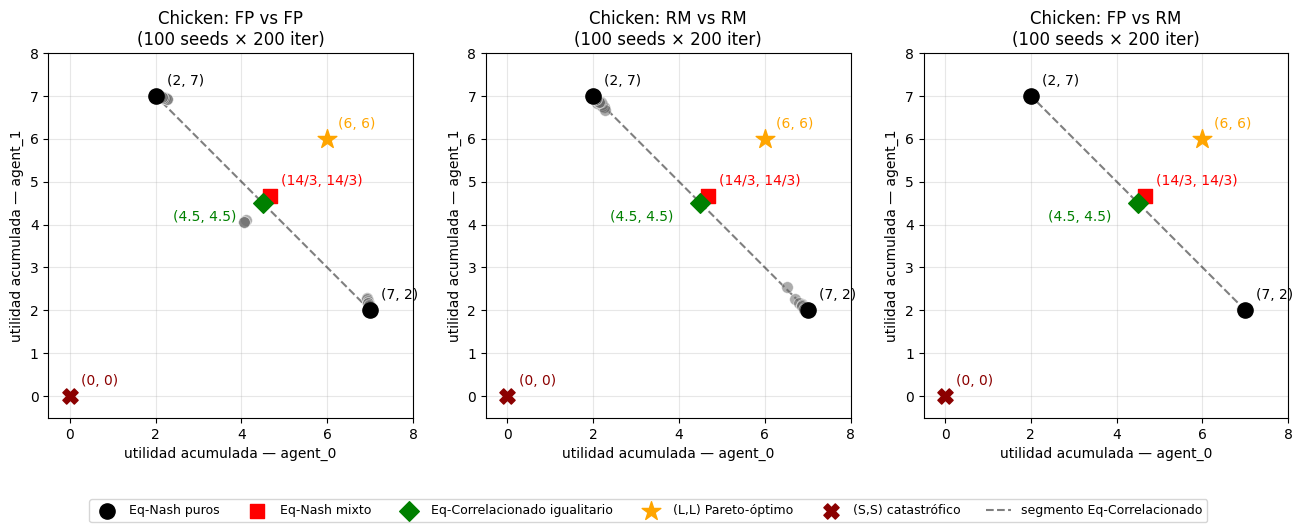


Utilidad promedio sobre seeds:
  FP vs FP: (4.682, 4.346)
  RM vs RM: (4.298, 4.681)
  FP vs RM: (3.008, 5.995)


In [29]:
def run_utility_scatter_chicken():
    results = {name: [] for name in chicken_pairs}
    for name, pair in chicken_pairs.items():
        for seed in SEEDS_MANY:
            g = Chicken(); g.reset()
            agents = {}
            for idx, agent_name in enumerate(g.agents):
                AgentClass, kw = pair[idx]
                kw = dict(kw); kw['seed'] = seed + idx
                agents[agent_name] = AgentClass(game=g, agent=agent_name, **kw)
            result = exp.play_oneshot(g, agents, ITER_FEW)
            r0, r1 = reward_history_from_actions(result['action_history'])
            results[name].append((float(r0.mean()), float(r1.mean())))
        log.info(f'{name}: utility scatter listo ({len(SEEDS_MANY)} seeds × {ITER_FEW} iter)')
    return {k: np.array(v) for k, v in results.items()}


chicken_utility_scatter = cached('chicken_utility_scatter', run_utility_scatter_chicken)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pts) in zip(axes, chicken_utility_scatter.items()):
    plot_utility_space(
        equilibria=CHICKEN_EQUILIBRIA,
        segments=CHICKEN_SEGMENTS,
        scatter=pts,
        scatter_color='dimgray',
        annotate_equilibria=True,
        ax=ax,
        title=f'Chicken: {name}\n({len(pts)} seeds × {ITER_FEW} iter)',
        xlim=(-0.5, 8),
        ylim=(-0.5, 8),
        xlabel='utilidad acumulada — agent_0',
        ylabel='utilidad acumulada — agent_1',
        show_legend=False,
    )

# Leyenda única abajo solo con equilibrios/segmento.
handles_all, labels_all = [], []
seen = set()
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in seen:
            handles_all.append(hi)
            labels_all.append(li)
            seen.add(li)
fig.legend(handles_all, labels_all, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=len(labels_all), fontsize=9, frameon=True)

savefig('chicken/utility_space_scatter')
plt.show()

print('\nUtilidad promedio sobre seeds:')
for name, pts in chicken_utility_scatter.items():
    mean_r0 = float(pts[:, 0].mean())
    mean_r1 = float(pts[:, 1].mean())
    print(f'  {name}: ({mean_r0:.3f}, {mean_r1:.3f})')


---

**Notas**:

- Los `history` dicts quedan persistidos en `data/chicken/chicken_history_*.pkl`. Por defecto `exp.cached_run` viene con `force=True` y re-ejecuta cada vez; pasar `force=False` para reutilizar el cache si la corrida es costosa.
- Las figuras se guardan en `images/chicken/` y son referenciadas desde `docs/informe/informe.md`.
- Configuración usada: `ITERATIONS=10000` (single-seed), `SEEDS=range(100)` × `ITER_FEW=200` (multi-seed corto). Las políticas convergen típicamente en menos de 100 iteraciones, así que las 10000 dejan amplio margen de meseta; los 100 seeds dan buena resolución estadística para los scatters.